--- Confusion Matrix ---
[[44  2]
 [ 2 42]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        46
           1       0.95      0.95      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



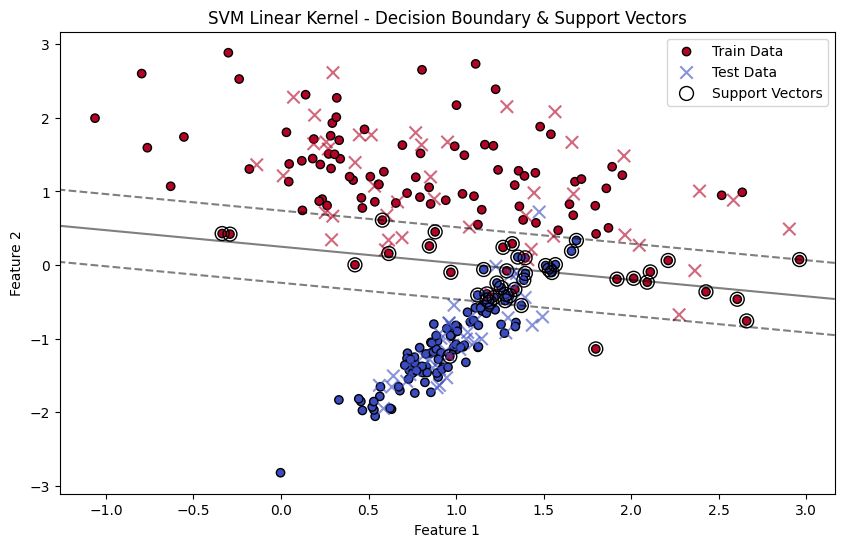

In [4]:
# SVM

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate a random synthetic 2D dataset
# We use 2 features so we can easily plot the results on a 2D graph
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1
)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train the SVM Classifier
# We'll use a linear kernel first; you can change this to 'rbf' for non-linear data
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = svm_model.predict(X_test)

# 5. Evaluate the model
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 6. Plot the Decision Boundary
plt.figure(figsize=(10, 6))

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', label='Train Data')
# Highlight the test points with a different marker
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='x', s=80, alpha=0.6, label='Test Data')

# Create a mesh grid to plot the decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Highlight support vectors
ax.scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors='none',
    edgecolors='k',
    label='Support Vectors'
)

plt.title('SVM Linear Kernel - Decision Boundary & Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

--- Classification Report (RBF Kernel) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        52

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



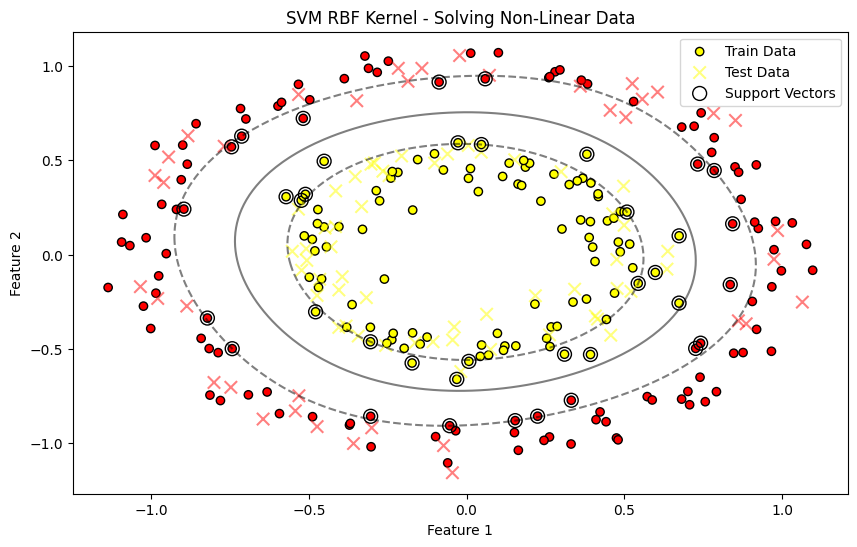

In [2]:
# Kernel Trick for Non-Linear Data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Generate a non-linear synthetic dataset (concentric circles)
X, y = make_circles(n_samples=300, noise=0.07, factor=0.5, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train the SVM with the RBF Kernel (Kernel Trick)
# 'rbf' stands for Radial Basis Function. 'gamma' controls the radius of influence.
kernel_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
kernel_svm.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = kernel_svm.predict(X_test)
print("--- Classification Report (RBF Kernel) ---")
print(classification_report(y_test, y_pred))

# 5. Plot the Non-Linear Decision Boundary
plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='autumn', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='autumn', marker='x', s=80, alpha=0.5, label='Test Data')

# Create a grid to plot decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Calculate decision function values over the grid
Z = kernel_svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Highlight support vectors chosen by the kernel
ax.scatter(
    kernel_svm.support_vectors_[:, 0],
    kernel_svm.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors='none',
    edgecolors='k',
    label='Support Vectors'
)

plt.title('SVM RBF Kernel - Solving Non-Linear Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        52

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



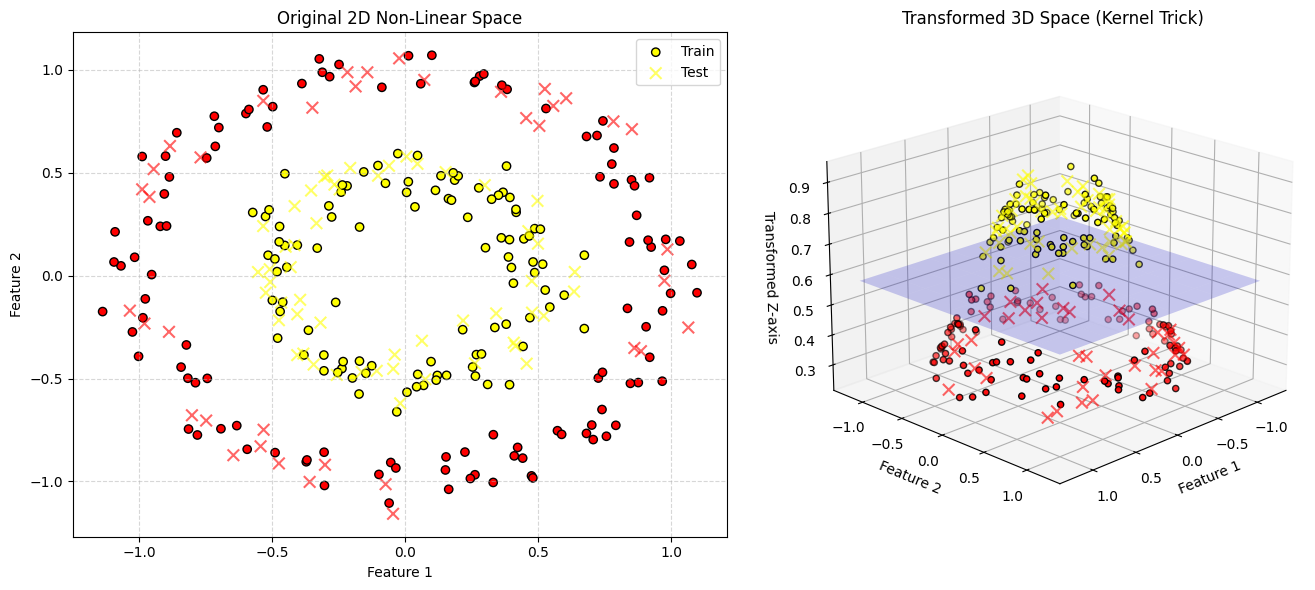

In [3]:
# 3D Plotting to Understand Kernel Trick
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Generate a non-linear synthetic dataset (concentric circles)
X, y = make_circles(n_samples=300, noise=0.07, factor=0.5, random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train the SVM with the RBF Kernel
kernel_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
kernel_svm.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = kernel_svm.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Create the Visualization (2D vs 3D Mapping)
fig = plt.figure(figsize=(14, 6))

# --- Plot 1: Original 2D Space ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='autumn', edgecolors='k', label='Train')
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='autumn', marker='x', s=70, alpha=0.6, label='Test')
ax1.set_title('Original 2D Non-Linear Space')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# --- Plot 2: Transformed 3D Space ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Explicitly compute the 3D projection mimicking the RBF behavior
# z = exp(-(x^2 + y^2)) lifts the center points upward
z_train = np.exp(-(X_train[:, 0]**2 + X_train[:, 1]**2))
z_test = np.exp(-(X_test[:, 0]**2 + X_test[:, 1]**2))

# Scatter plot the 3D points
ax2.scatter(X_train[:, 0], X_train[:, 1], z_train, c=y_train, cmap='autumn', edgecolors='k')
ax2.scatter(X_test[:, 0], X_test[:, 1], z_test, c=y_test, cmap='autumn', marker='x', s=70, alpha=0.6)

# Create a flat 2D separating hyperplane in the 3D space
xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 10), np.linspace(-1.2, 1.2, 10))
# The inner circle sits around z=0.77 and outer circle around z=0.36; 0.58 splits them perfectly
zz = np.ones_like(xx) * 0.58
ax2.plot_surface(xx, yy, zz, alpha=0.2, color='blue')

ax2.set_title('Transformed 3D Space (Kernel Trick)')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Transformed Z-axis')

# Adjust the camera angle for optimal viewing
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()